# Titanic Dataset -Survival Analysis

In [1]:
import pandas as pd 

df=pd.read_csv("train.csv")

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [3]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

#  Clean dataset:

In [4]:
import pandas as pd

df = pd.read_csv('train.csv')

# Impute missing Age values
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Impute with the mode ('S')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop the Cabin column 
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

df.to_csv('train.csv', index=False)

# Analysis Questions:

In [5]:
# Survival Rate by Age Group
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Middle Aged (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.groupby('AgeGroup', observed=False)['Survived'].agg(
    Total='count',
    Survived='sum',
    Survival_Rate=lambda x: f"{x.mean() * 100:.2f}%"
)

,Total,Survived,Survival_Rate
AgeGroup,,,
Child (0-12),69,40,57.97%
Teen (13-18),70,30,42.86%
Young Adult (19-35),535,189,35.33%
Middle Aged (36-60),195,78,40.00%
Senior (60+),22,5,22.73%


In [6]:
# Survival Rate by Embarkation Port
df.groupby('Embarked')['Survived'].agg(
    Total='count',
    Survived='sum',
    Survival_Rate=lambda x: f"{x.mean() * 100:.2f}%"
)

,Total,Survived,Survival_Rate
Embarked,,,
C,168,93,55.36%
Q,77,30,38.96%
S,646,219,33.90%


In [7]:
# Survival Rate by Family Size (SibSp + Parch)
df['FamilySize'] = df['SibSp'] + df['Parch']

df['FamilyCategory'] = pd.cut(
    df['FamilySize'],
    bins=[-1, 0, 3, 10],
    labels=['Alone (0)', 'Small Family (1-3)', 'Large Family (4+)']
)

df.groupby('FamilyCategory', observed=False)['Survived'].agg(
    Total='count',
    Survived='sum',
    Survival_Rate=lambda x: f"{x.mean() * 100:.2f}%"
)

,Total,Survived,Survival_Rate
FamilyCategory,,,
Alone (0),537,163,30.35%
Small Family (1-3),292,169,57.88%
Large Family (4+),62,10,16.13%


# Visualizations:

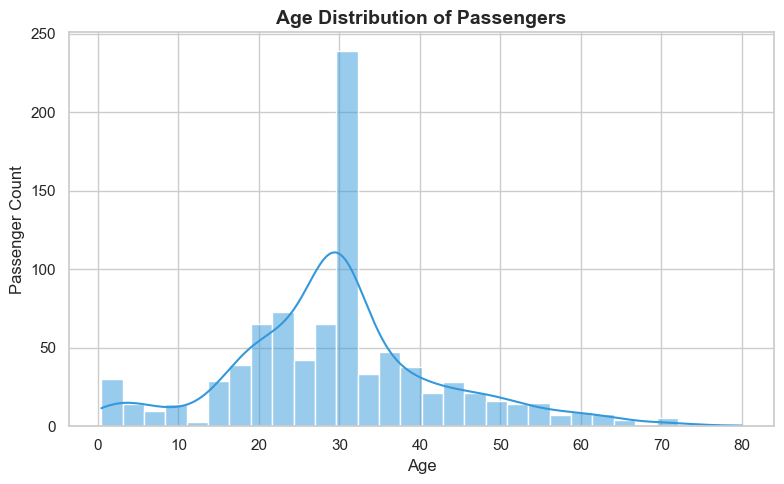

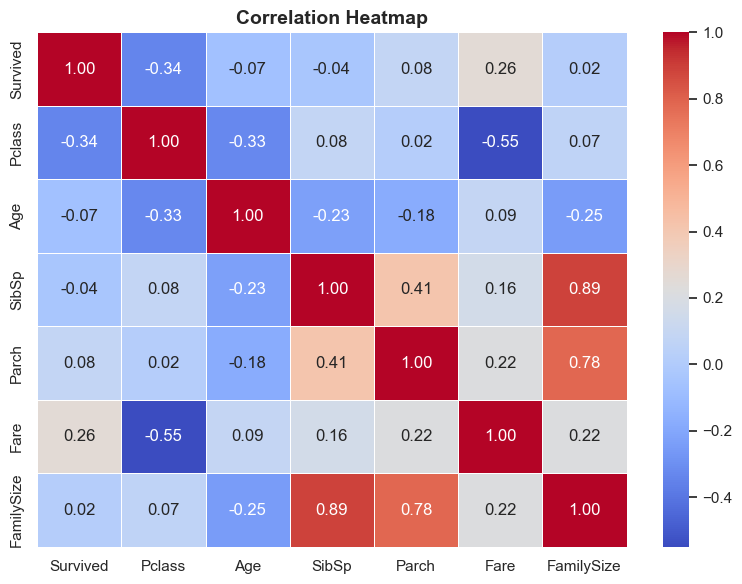

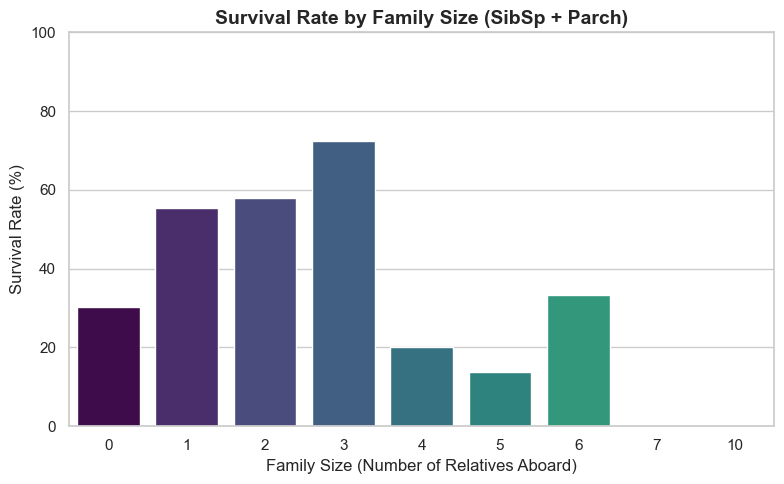

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('train.csv')

# Preprocessing
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['FamilySize'] = df['SibSp'] + df['Parch']

sns.set_theme(style="whitegrid")

# 1. Age Distribution Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, bins=30, color='#3498db')
plt.title('Age Distribution of Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['PassengerId'], errors='ignore')
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Survival Rate by Family Size
fam_survival = df.groupby('FamilySize', as_index=False)['Survived'].mean()
fam_survival['SurvivalRate_%'] = fam_survival['Survived'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=fam_survival, x='FamilySize', y='SurvivalRate_%', palette='viridis', hue='FamilySize', legend=False)
plt.title('Survival Rate by Family Size (SibSp + Parch)', fontsize=14, fontweight='bold')
plt.xlabel('Family Size (Number of Relatives Aboard)')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()